# Weather Utility — Example Notebook

This notebook demonstrates how to call the public functions in `utils/weather_utils.py` and inspect their outputs.

## Public functions covered
- `load_weather_config`
- `build_weather_for_household_calendar`
- `fetch_raw_historical_weather`
- `build_full_weather_15min`
- `add_derived_weather_features`

In [2]:
import sys
from pathlib import Path

# Ensure notebook imports resolve from project root and src/
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "utils").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"

for p in (PROJECT_ROOT, SRC_DIR):
    p_str = str(p)
    if p_str not in sys.path:
        sys.path.insert(0, p_str)

import matplotlib.pyplot as plt
import pandas as pd

# Make sure project root is importable when notebook runs from notebooks/
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from utils.weather_utils import (
    add_derived_weather_features,
    build_full_weather_15min,
    build_weather_for_household_calendar,
    fetch_raw_historical_weather,
    load_weather_config,
)

print(f"Project root: {root}")

Project root: /Users/joscham/work/hems-automation


## 1) Load config and define a sample calendar

We build a small 2-day 15-minute UTC calendar to keep this example fast.

In [3]:
config = load_weather_config("user_config.json")
print({k: config[k] for k in ["lat", "lon"]})

sample_start = pd.Timestamp("2025-01-15 00:00:00", tz="UTC")
sample_end = pd.Timestamp("2025-01-16 23:45:00", tz="UTC")
calendar_index = pd.date_range(sample_start, sample_end, freq="15min")
household_calendar = pd.DataFrame({"utc_timestamp": calendar_index})

print(f"Calendar rows: {len(household_calendar)}")
household_calendar.head(3)

{'lat': 47.659216, 'lon': 9.1750718}
Calendar rows: 192


,utc_timestamp
0,2025-01-15 00:00:00+00:00
1,2025-01-15 00:15:00+00:00
2,2025-01-15 00:30:00+00:00


## 2) End-to-end call: `build_weather_for_household_calendar`

This runs the full pipeline (fetch raw hourly weather + interpolate to 15-minute table).

In [4]:
weather_15min = build_weather_for_household_calendar(
    household_timestamps=household_calendar,
    config_path="user_config.json",
    include_derived=False,
)

print(f"Rows: {len(weather_15min)}")
print(f"Columns: {len(weather_15min.columns)}")
weather_15min.head(5)

Rows: 192
Columns: 27


,utc_timestamp,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,direct_radiation,diffuse_radiation,global_tilted_irradiance,sunshine_duration,wind_speed_10m,wind_direction_10m,wind_gusts_10m,et0_fao_evapotranspiration,vapour_pressure_deficit,source
0,2025-01-15 00:00:00+00:00,-4.20,79.00,-7.3,-7.50,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.200,256.0,4.7,0.0,0.0900,open_meteo_interpolated
1,2025-01-15 00:15:00+00:00,-4.05,83.25,-6.5,-7.35,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.775,256.0,5.6,0.0,0.0725,open_meteo_interpolated
2,2025-01-15 00:30:00+00:00,-3.90,87.50,-5.7,-7.20,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,3.350,256.0,6.5,0.0,0.0550,open_meteo_interpolated
3,2025-01-15 00:45:00+00:00,-3.75,91.75,-4.9,-7.05,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,3.925,256.0,7.4,0.0,0.0375,open_meteo_interpolated
4,2025-01-15 01:00:00+00:00,-3.60,96.00,-4.1,-6.90,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,4.500,256.0,8.3,0.0,0.0200,open_meteo_interpolated


## 3) Individual function calls

Below we call the lower-level helpers directly to show what each one returns.

In [5]:
raw_weather = fetch_raw_historical_weather(
    household_calendar=household_calendar,
    config_path="user_config.json",
)

print(f"Raw hourly rows: {len(raw_weather)}")
raw_weather[["time", "temperature_2m", "cloud_cover", "source"]].head(5)

Raw hourly rows: 48


,time,temperature_2m,cloud_cover,source
0,2025-01-15 00:00:00+00:00,-4.2,37,open_meteo_archive
1,2025-01-15 01:00:00+00:00,-3.6,38,open_meteo_archive
2,2025-01-15 02:00:00+00:00,-3.3,100,open_meteo_archive
3,2025-01-15 03:00:00+00:00,-2.8,100,open_meteo_archive
4,2025-01-15 04:00:00+00:00,-2.2,94,open_meteo_archive


In [6]:
full_15min = build_full_weather_15min(
    raw_weather_df=raw_weather,
    household_calendar=household_calendar,
)

print(f"Interpolated 15-min rows: {len(full_15min)}")
full_15min[["utc_timestamp", "temperature_2m", "wind_speed_10m", "source"]].head(5)

Interpolated 15-min rows: 192


,utc_timestamp,temperature_2m,wind_speed_10m,source
0,2025-01-15 00:00:00+00:00,-4.20,2.200,open_meteo_interpolated
1,2025-01-15 00:15:00+00:00,-4.05,2.775,open_meteo_interpolated
2,2025-01-15 00:30:00+00:00,-3.90,3.350,open_meteo_interpolated
3,2025-01-15 00:45:00+00:00,-3.75,3.925,open_meteo_interpolated
4,2025-01-15 01:00:00+00:00,-3.60,4.500,open_meteo_interpolated


In [7]:
derived = add_derived_weather_features(full_15min)

derived_cols = [
    "heating_degree_18c",
    "cooling_degree_22c",
    "is_raining",
    "is_snowing",
    "is_dark",
    "wind_u_10m",
    "wind_v_10m",
]

print("Derived columns added:")
print(derived_cols)
derived[["utc_timestamp", *derived_cols]].head(5)

Derived columns added:
['heating_degree_18c', 'cooling_degree_22c', 'is_raining', 'is_snowing', 'is_dark', 'wind_u_10m', 'wind_v_10m']


,utc_timestamp,heating_degree_18c,cooling_degree_22c,is_raining,is_snowing,is_dark,wind_u_10m,wind_v_10m
0,2025-01-15 00:00:00+00:00,22.20,0.0,0,0,1,-0.532228,-2.134651
1,2025-01-15 00:15:00+00:00,22.05,0.0,0,0,1,-0.671333,-2.692571
2,2025-01-15 00:30:00+00:00,21.90,0.0,0,0,1,-0.810438,-3.250491
3,2025-01-15 00:45:00+00:00,21.75,0.0,0,0,1,-0.949543,-3.808411
4,2025-01-15 01:00:00+00:00,21.60,0.0,0,0,1,-1.088649,-4.366331


## 4) Short EDA of the 15-minute weather output

In [8]:
eda_df = weather_15min.copy()

print("Shape:", eda_df.shape)
print()
print("dtypes (first 10):")
print(eda_df.dtypes.head(10))
print()
eda_df[["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "precipitation"]].describe()

Shape: (192, 27)

dtypes (first 10):
utc_timestamp           datetime64[ns, UTC]
temperature_2m                      float64
relative_humidity_2m                float64
dew_point_2m                        float64
apparent_temperature                float64
precipitation                       float64
rain                                float64
snowfall                            float64
snow_depth                          float64
weather_code                        float64
dtype: object



,temperature_2m,relative_humidity_2m,wind_speed_10m,precipitation
count,192.000000,192.000000,192.000000,192.000000
mean,0.470312,84.859375,9.408594,0.012500
std,1.806037,8.091817,5.492331,0.041723
min,-4.200000,64.000000,0.700000,0.000000
25%,-0.712500,78.250000,4.237500,0.000000
50%,0.900000,87.500000,9.300000,0.000000
75%,1.356250,92.000000,12.812500,0.000000
max,4.200000,96.000000,19.400000,0.200000


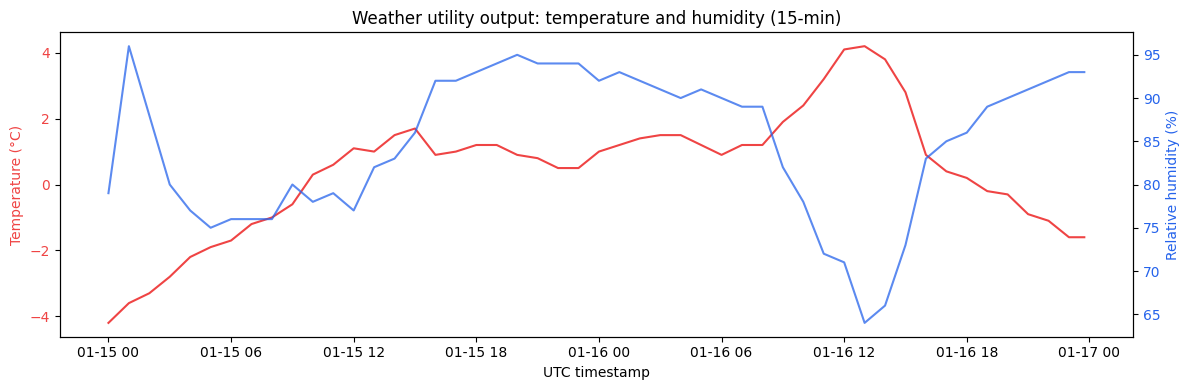

In [9]:
fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.plot(eda_df["utc_timestamp"], eda_df["temperature_2m"], color="#ef4444", label="temperature_2m")
ax1.set_xlabel("UTC timestamp")
ax1.set_ylabel("Temperature (°C)", color="#ef4444")
ax1.tick_params(axis="y", labelcolor="#ef4444")

ax2 = ax1.twinx()
ax2.plot(eda_df["utc_timestamp"], eda_df["relative_humidity_2m"], color="#2563eb", alpha=0.75, label="relative_humidity_2m")
ax2.set_ylabel("Relative humidity (%)", color="#2563eb")
ax2.tick_params(axis="y", labelcolor="#2563eb")

ax1.set_title("Weather utility output: temperature and humidity (15-min)")
fig.tight_layout()
plt.show()